First examples

3. A personal assistant that observes incoming messages to decide which of them to forward to the client.


## Utility

np.float64(0.015698833992807113)

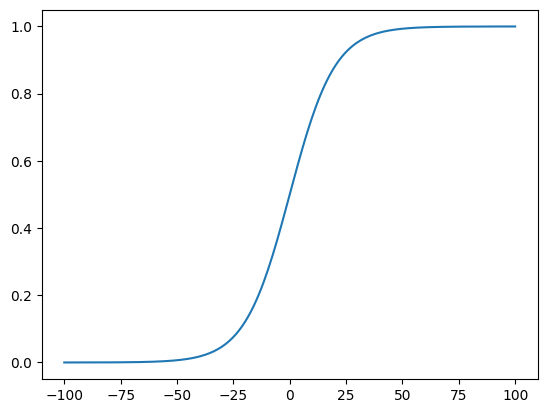

In [1]:
import numpy as np
from matplotlib import pyplot as plt

def utility(r, alpha=0.1):
    return 1 / (1+np.exp(-alpha*r))# 10*np.log2(w+2*r+1)

def expected_utility(c, terms=50):
    res = 0
    for i in range(1, terms+1):
        res += utility(2**i - c) / 2**i
    return res

rs = np.linspace(-100, 100, 200)

plt.plot(rs, utility(rs))
expected_utility(100)

In [2]:
from scipy.optimize import fsolve

def u_sigmoid(w, alpha=0.01):
    return 1 / (1 + np.exp(-alpha * w))

def objective(c, W=-1000):
    expected_u = sum(u_sigmoid(W + 2**i - c) / 2**i for i in range(1, 40))
    return expected_u - u_sigmoid(W)

fair_price = fsolve(objective, x0=0)[0]
fair_price

/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_86982/1574370303.py:10: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  fair_price = fsolve(objective, x0=0)[0]


np.float64(20228.289795831435)

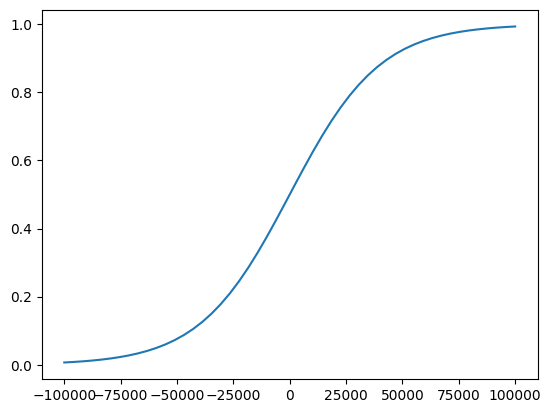

In [3]:
rs = np.linspace(-100000, 100000)
plt.plot(rs, u_sigmoid(rs, alpha=0.00005))

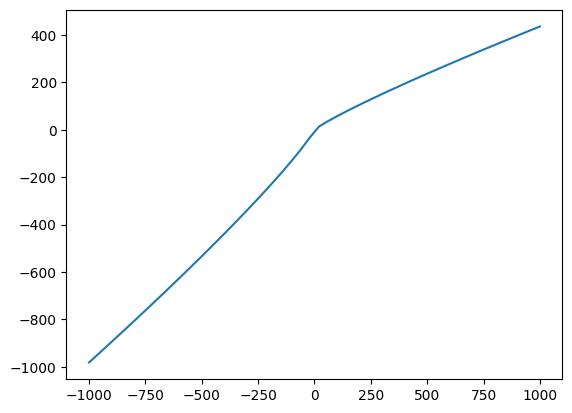

In [4]:
def prospect_utility(x, alpha=0.88, beta=0.88, lam=2.25):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    np.power(x, alpha, where=x >= 0, out=out)
    np.power(-x, beta, where=x<0, out=out)
    np.multiply(out, -lam, where=x<0, out=out)
    return out

rs = np.linspace(-1000, 1000)
plt.plot(rs, prospect_utility(rs))